In [1]:
import pandas as pd

# Load data
df = pd.read_csv('salary_data.csv')
print("Original shape:", df.shape)
print(df.head())

# Check quality
print("\nNull values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

# Clean: remove duplicates and negatives
df = df.drop_duplicates()
df = df[(df['YearsExperience'] >= 0) & (df['Salary'] >= 0)]
print("\nCleaned shape:", df.shape)
print(df.describe())


Original shape: (30, 2)
   YearsExperience   Salary
0              1.1  39343.0
1              1.3  46205.0
2              1.5  37731.0
3              2.0  43525.0
4              2.2  39891.0

Null values:
 YearsExperience    0
Salary             0
dtype: int64

Duplicates: 0

Cleaned shape: (30, 2)
       YearsExperience         Salary
count        30.000000      30.000000
mean          5.313333   76003.000000
std           2.837888   27414.429785
min           1.100000   37731.000000
25%           3.200000   56720.750000
50%           4.700000   65237.000000
75%           7.700000  100544.750000
max          10.500000  122391.000000


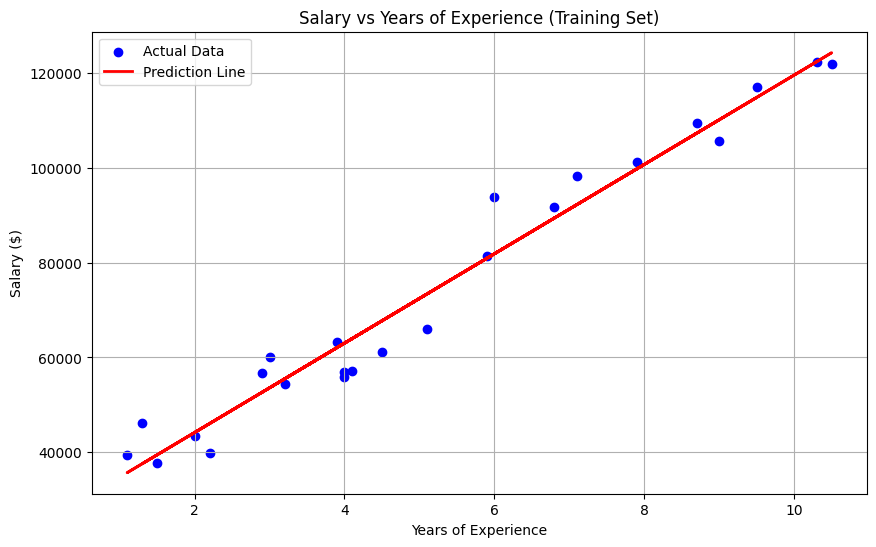

In [6]:
import matplotlib.pyplot as plt

# Better Visualization: Experience vs Salary
plt.figure(figsize=(10, 6))

# 1. Plot the actual data points (Blue Dots)
plt.scatter(X_train, y_train, color='blue', label='Actual Data')

# 2. Plot the regression line (Red Line)
plt.plot(X_train, model.predict(X_train), color='red', linewidth=2, label='Prediction Line')

# Labels
plt.title('Salary vs Years of Experience (Training Set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary ($)')
plt.legend()
plt.grid(True)
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Prepare features (X) and target (y)
X = df[['YearsExperience']]  # 2D array needed
y = df['Salary']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Test model
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2:.4f}")
print(f"Model equation: Salary = {model.coef_[0]:.2f} * Experience + {model.intercept_:.2f}")


R² Score: 0.9024
Model equation: Salary = 9423.82 * Experience + 25321.58


In [5]:
import joblib

joblib.dump(model, 'salary_model.pkl')
print("✅ Model saved as 'salary_model.pkl'")


✅ Model saved as 'salary_model.pkl'
